In [ ]:
# Import modules
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import Voronoi, voronoi_plot_2d
from shapely.geometry import box
from shapely.geometry import Polygon, Point
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
watershed = gpd.read_file("/content/hbef_wsheds.shp")
wshed_crs = watershed.crs
raingauge = gpd.read_file("/content/hbef_raingauges.shp")
raingauge.to_crs(wshed_crs, inplace=True)
precip = pd.read_csv("/content/HubbardBrookHourlyPrecip.csv")
display(precip)

# Extend extent of counties feature by using buffer
watershed_buffer = watershed.buffer(100000)

# Get extent of buffered input feature
min_x_cty_tp, min_y_cty_tp, max_x_cty_tp, max_y_cty_tp = watershed_buffer.total_bounds

,DateTime,RG1,RG2,RG4,RG6,RG9,RG14,RG17,RG19,RG22,RG23
0,6/21/2011 13:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1,6/21/2011 14:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,6/21/2011 15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
3,6/21/2011 16:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
4,6/21/2011 17:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
113478,5/31/2024 19:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
113479,5/31/2024 20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
113480,5/31/2024 21:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
113481,5/31/2024 22:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Get all combination of raingauges
precip = precip.drop([x for x in ["Row", "DateTime"] if x in precip.columns], axis=1)
precip["whichgauges"] = precip[precip.columns.tolist()].apply(
    lambda x: x.isna().tolist(), axis=1
)
display(precip)


,RG1,RG2,RG4,RG6,RG9,RG14,RG17,RG19,RG22,RG23,whichgauges
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal..."
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal..."
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal..."
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal..."
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal..."
...,...,...,...,...,...,...,...,...,...,...,...
113478,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[False, False, False, False, False, False, Fal..."
113479,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[False, False, False, False, False, False, Fal..."
113480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[False, False, False, False, False, False, Fal..."
113481,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[False, False, False, False, False, False, Fal..."


In [ ]:
gauge_lists = precip["whichgauges"]

# Convert inner lists to tuples and add to a set
unique_gauge_tuples = set(tuple(one_gauge_list) for one_gauge_list in gauge_lists)

# Convert unique tuples back to lists
unique_gauge_lists = [list(tup) for tup in unique_gauge_tuples]

unique_mapping = {item: i for i, item in enumerate(unique_gauge_tuples)}

# Number the original series
numbered_series = []
for sublist in gauge_lists:
    numbered_series.append(unique_mapping[tuple(sublist)])

# Add back into the precip array
precip["which_gauge_set"] = numbered_series

print(unique_gauge_lists)
display(precip.head(5))

[[True, True, True, True, True, True, True, False, True, False], [False, True, True, False, True, True, True, False, True, False], [False, True, True, False, True, False, True, False, True, False], [False, True, False, False, False, False, True, False, False, False], [False, False, False, False, False, False, True, False, False, False], [False, True, True, False, False, False, True, False, False, False], [False, True, True, True, True, True, True, False, True, False], [False, False, False, False, False, False, False, False, False, False], [False, True, True, False, True, False, True, False, False, False], [True, True, True, True, True, True, True, False, True, True]]


,RG1,RG2,RG4,RG6,RG9,RG14,RG17,RG19,RG22,RG23,whichgauges,which_gauge_set
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9


In [ ]:
display(unique_gauge_lists)

print("gap")

for gauge_set in unique_gauge_lists:
    gauge_set = [not value for value in gauge_set]
    print(gauge_set)

[[True, True, True, True, True, True, True, False, True, False],
 [False, True, True, False, True, True, True, False, True, False],
 [False, True, True, False, True, False, True, False, True, False],
 [False, True, False, False, False, False, True, False, False, False],
 [False, False, False, False, False, False, True, False, False, False],
 [False, True, True, False, False, False, True, False, False, False],
 [False, True, True, True, True, True, True, False, True, False],
 [False, False, False, False, False, False, False, False, False, False],
 [False, True, True, False, True, False, True, False, False, False],
 [True, True, True, True, True, True, True, False, True, True]]

gap
[False, False, False, False, False, False, False, True, False, True]
[True, False, False, True, False, False, False, True, False, True]
[True, False, False, True, False, True, False, True, False, True]
[True, False, True, True, True, True, False, True, True, True]
[True, True, True, True, True, True, False, True, True, True]
[True, False, False, True, True, True, False, True, True, True]
[True, False, False, False, False, False, False, True, False, True]
[True, True, True, True, True, True, True, True, True, True]
[True, False, False, True, False, True, False, True, True, True]
[False, False, False, False, False, False, False, True, False, False]


In [ ]:
frac_lists = []

for gauge_set in unique_gauge_lists:
    # Converts from 'is nan' to 'is a gauged value'
    gauge_set = [not value for value in gauge_set]
    # print(gauge_set)

    # Create the Thiessen values

    # Subset the raingauge list
    raingauge_subset = raingauge.loc[gauge_set, :]

    # Get minimum and maximum coordinate values of rainfall training points
    min_x_rain, min_y_rain, max_x_rain, max_y_rain = raingauge_subset.total_bounds

    # Use extent to create dummy points and add them to list of coordinates
    rain_coords = raingauge_subset.get_coordinates()
    rain_coords = rain_coords.values.tolist()
    coords_tp = rain_coords + [
        [min_x_cty_tp, min_y_cty_tp],
        [max_x_cty_tp, min_y_cty_tp],
        [max_x_cty_tp, max_y_cty_tp],
        [min_x_cty_tp, max_y_cty_tp],
    ]

    # Compute Voronoi diagram
    tp = Voronoi(coords_tp)

    # Create empty list of hold Voronoi polygons
    tp_poly_list = []

    # Create a polygon for each region
    # 'regions' attribute provides a list of indices of the vertices (in the 'vertices' attribute) that make up the region
    # Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.Voronoi.html
    for region in tp.regions:
        # Ignore region if -1 is in the list (based on documentation)
        if -1 in region:
            # Return to top of loop
            continue

        # Otherwise, pass
        else:
            pass

        # Check that region list has values in it
        if len(region) != 0:
            # Create a polygon by using the region list to call the correct elements in the 'vertices' attribute
            tp_poly_region = Polygon(list(tp.vertices[region]))

            # Append polygon to list
            tp_poly_list.append(tp_poly_region)

        # If no values, return to top of loop
        else:
            continue

    # Create GeoDataFrame from list of polygon regions
    tp_polys = gpd.GeoDataFrame(tp_poly_list, columns=["geometry"], crs=wshed_crs)

    # Clip polygon regions to the watershed boundary
    tp_polys_clipped = gpd.clip(tp_polys, watershed)

    # If rainfall point within the polygon, assign that rainfall value to the polygon
    tp_polys_clipped_values = gpd.sjoin(
        raingauge_subset, tp_polys_clipped, how="right", predicate="within"
    )

    # Drop un-needed column
    tp_polys_clipped_values = tp_polys_clipped_values.drop("index_left", axis=1)

    # Get area of each thiessen polygon
    tp_polys_clipped_values["area_sq_km"] = (
        tp_polys_clipped_values.geometry.area / 1000000
    )

    # Calculate the sum of all polygon areas
    total_area_sqkm = tp_polys_clipped_values["area_sq_km"].sum()

    # Get fractional area of each thiessen polygon
    tp_polys_clipped_values["area_frac"] = (
        tp_polys_clipped_values["area_sq_km"] / total_area_sqkm
    )

    # Display head of attribute table
    print("Attribute Table: Thiessen Polygon Interpolated Values")
    # display(tp_polys_clipped_values.head())

    frac_lists.append(tp_polys_clipped_values[["geometry", "area_frac", "Rain_Gauge"]])

# display(frac_lists)


Attribute Table: Thiessen Polygon Interpolated Values
Attribute Table: Thiessen Polygon Interpolated Values
Attribute Table: Thiessen Polygon Interpolated Values
Attribute Table: Thiessen Polygon Interpolated Values
Attribute Table: Thiessen Polygon Interpolated Values
Attribute Table: Thiessen Polygon Interpolated Values
Attribute Table: Thiessen Polygon Interpolated Values
Attribute Table: Thiessen Polygon Interpolated Values
Attribute Table: Thiessen Polygon Interpolated Values
Attribute Table: Thiessen Polygon Interpolated Values


In [ ]:
# Order these by the raingauge number
for i, item in enumerate(frac_lists):
    item2 = item
    item2["Rain_Gauge"] = item2["Rain_Gauge"].str.replace("RG", "")
    item2["Rain_Gauge"] = item2["Rain_Gauge"].astype(int)
    item2 = item2.sort_values(by=["Rain_Gauge"])
    display(item2)
    frac_lists[i] = item2

# display([frac_lists, frac_name])
# combined_data = list(zip(frac_lists['area_frac'], frac_name['RainGauge']))
# frac_df = pd.DataFrame(combined_data, columns=['Frac', 'RainGauge'])


,geometry,area_frac,Rain_Gauge
1,"POLYGON ((278683.358 4866432.662, 278678.481 4...",0.568683,19
0,"POLYGON ((279872.932 4870777.745, 279877.384 4...",0.431317,23


,geometry,area_frac,Rain_Gauge
2,"POLYGON ((279959.101 4869132.673, 281574.9 487...",0.215668,1
0,"POLYGON ((279959.101 4869132.673, 279466.573 4...",0.124138,6
1,"POLYGON ((278683.358 4866432.662, 278678.481 4...",0.494942,19
3,"POLYGON ((281681.689 4867947.069, 281675.183 4...",0.165252,23


,geometry,area_frac,Rain_Gauge
3,"POLYGON ((279959.101 4869132.673, 281574.9 487...",0.215668,1
1,"POLYGON ((279959.101 4869132.673, 279466.573 4...",0.124138,6
0,"POLYGON ((278819.043 4866928.27, 279089.278 48...",0.153232,14
2,"POLYGON ((278819.043 4866928.27, 275171.34 486...",0.345807,19
4,"POLYGON ((281681.689 4867947.069, 281675.183 4...",0.161156,23


,geometry,area_frac,Rain_Gauge
2,"POLYGON ((282248.906 4869599.765, 281471.22 48...",0.092251,1
5,"POLYGON ((281230.961 4871038.36, 281240.118 48...",0.034361,4
7,"POLYGON ((281151.844 4870706.542, 280508.433 4...",0.016272,6
6,"POLYGON ((280508.433 4869857.537, 280210.389 4...",0.168333,9
0,"POLYGON ((278819.043 4866928.27, 279089.278 48...",0.153232,14
1,"POLYGON ((278819.043 4866928.27, 275171.34 486...",0.291903,19
4,"POLYGON ((282803.955 4870258.943, 282806.707 4...",0.086297,22
3,"POLYGON ((278819.043 4866928.27, 279410.877 48...",0.157350,23


,geometry,area_frac,Rain_Gauge
8,"POLYGON ((282248.906 4869599.765, 281471.22 48...",0.086417,1
5,"POLYGON ((281444.997 4870410.793, 280608.973 4...",0.014373,2
6,"POLYGON ((282248.906 4869599.765, 281444.997 4...",0.030270,4
7,"POLYGON ((280508.433 4869857.537, 280283.443 4...",0.011825,6
4,"POLYGON ((280508.433 4869857.537, 280210.389 4...",0.168333,9
0,"POLYGON ((278819.043 4866928.27, 279089.278 48...",0.153232,14
1,"POLYGON ((278819.043 4866928.27, 275171.34 486...",0.291903,19
3,"POLYGON ((282803.955 4870258.943, 282806.707 4...",0.086297,22
2,"POLYGON ((278819.043 4866928.27, 279410.877 48...",0.157350,23


...

,geometry,area_frac,Rain_Gauge
2,"POLYGON ((278269.06 4870893.2, 278269.273 4870...",0.302347,1
1,"POLYGON ((279507.625 4869443.41, 278683.358 48...",0.531135,19
0,"POLYGON ((279507.625 4869443.41, 281681.689 48...",0.166519,23


,geometry,area_frac,Rain_Gauge
8,"POLYGON ((281444.997 4870410.793, 282248.906 4...",0.086417,1
6,"POLYGON ((281444.997 4870410.793, 280608.973 4...",0.014373,2
7,"POLYGON ((282248.906 4869599.765, 281444.997 4...",0.030270,4
9,"POLYGON ((280608.973 4869990.204, 280508.433 4...",0.011825,6
5,"POLYGON ((280508.433 4869857.537, 280210.389 4...",0.168333,9
0,"POLYGON ((278435.597 4867147.946, 278113.639 4...",0.138793,14
1,"POLYGON ((278435.597 4867147.946, 278884.733 4...",0.023523,17
2,"POLYGON ((279410.877 4869090.026, 278884.733 4...",0.290227,19
4,"POLYGON ((281471.22 4868091.929, 282248.906 48...",0.086297,22
3,"POLYGON ((278884.733 4867168.215, 279410.877 4...",0.149942,23


,geometry,area_frac,Rain_Gauge
2,"POLYGON ((281471.22 4868091.929, 279959.101 48...",0.127466,1
5,"POLYGON ((279466.573 4869293.464, 276323.25 48...",0.124138,6
0,"POLYGON ((278819.043 4866928.27, 279089.278 48...",0.153232,14
1,"POLYGON ((278819.043 4866928.27, 275171.34 486...",0.345807,19
4,"POLYGON ((281471.22 4868091.929, 282600.602 48...",0.088628,22
3,"POLYGON ((278819.043 4866928.27, 279466.573 48...",0.160730,23


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,geometry,area_frac,Rain_Gauge
0,"POLYGON ((279704.593 4866609.879, 279699.656 4...",1.0,19


In [ ]:
display(frac_lists)

[                                            geometry  area_frac  Rain_Gauge
 1  POLYGON ((278683.358 4866432.662, 278678.481 4...   0.568683          19
 0  POLYGON ((279872.932 4870777.745, 279877.384 4...   0.431317          23,
                                             geometry  area_frac  Rain_Gauge
 2  POLYGON ((279959.101 4869132.673, 281574.9 487...   0.215668           1
 0  POLYGON ((279959.101 4869132.673, 279466.573 4...   0.124138           6
 1  POLYGON ((278683.358 4866432.662, 278678.481 4...   0.494942          19
 3  POLYGON ((281681.689 4867947.069, 281675.183 4...   0.165252          23,
                                             geometry  area_frac  Rain_Gauge
 3  POLYGON ((279959.101 4869132.673, 281574.9 487...   0.215668           1
 1  POLYGON ((279959.101 4869132.673, 279466.573 4...   0.124138           6
 0  POLYGON ((278819.043 4866928.27, 279089.278 48...   0.153232          14
 2  POLYGON ((278819.043 4866928.27, 275171.34 486...   0.345807          

Use a spatial join to assign the rainfall values to their associated Thiessen polygon.

In [ ]:
gauge_columns = [col for col in precip.columns if col.startswith("RG")]

# Build weights dictionary
weights_dict = {}
for i, frac_df in enumerate(frac_lists):
    gauges = frac_df["Rain_Gauge"].tolist()
    weights = np.zeros(len(gauge_columns))
    for j, col in enumerate(gauge_columns):
        gauge_id = int(col.replace("RG", "").strip())
        if gauge_id in gauges:
            val = frac_df.loc[frac_df["Rain_Gauge"] == gauge_id, "area_frac"].values
            if len(val) == 1:
                weights[j] = val[0]
            else:
                print(f"Warning: Gauge {gauge_id} not found in frac_df {i}")
    weights_dict[i] = weights

# Convert precipitation to numpy array
precip_values = precip[gauge_columns].to_numpy(dtype=float)

# Initialize weighted precip array
weighted_precip = np.zeros(precip_values.shape[0])

# Compute weighted average row by row
for idx, row in precip.iterrows():
    weight_idx = row["which_gauge_set"]
    weights = weights_dict[weight_idx]

    # Only use non-NaN precipitation values
    row_values = precip_values[idx, :]
    mask = ~np.isnan(row_values)
    if np.any(mask):
        weighted_precip[idx] = np.sum(row_values[mask] * weights[mask]) / np.sum(
            weights[mask]
        )
    else:
        weighted_precip[idx] = np.nan

# Add to DataFrame
precip["weighted_precip"] = weighted_precip

In [ ]:
precip.head(6277)

,RG1,RG2,RG4,RG6,RG9,RG14,RG17,RG19,RG22,RG23,whichgauges,which_gauge_set,weighted_precip
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9,0.000000
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9,0.000000
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9,0.000000
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9,0.000000
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6272,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,"[False, True, True, False, True, False, True, ...",2,0.000000
6273,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,"[False, True, True, False, True, False, True, ...",2,0.000000
6274,4.6,NaN,NaN,6.1,NaN,5.9,NaN,6.4,NaN,5.9,"[False, True, True, False, True, False, True, ...",2,5.817362
6275,2.4,NaN,NaN,1.6,NaN,1.8,NaN,2.4,NaN,1.8,"[False, True, True, False, True, False, True, ...",2,2.112057


Combine with timestamps

In [ ]:
# Read in original precip csv
precip_original = pd.read_csv("/content/HubbardBrookHourlyPrecip.csv")

# Add the DateTime column back
precip["DateTime"] = precip_original["DateTime"]

# Optional: move DateTime to the first column
cols = ["DateTime"] + [c for c in precip.columns if c != "DateTime"]
precip = precip[cols]

# Display first few rows
display(precip.head(6277))

,DateTime,RG1,RG2,RG4,RG6,RG9,RG14,RG17,RG19,RG22,RG23,whichgauges,which_gauge_set,weighted_precip
0,6/21/2011 13:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9,0.000000
1,6/21/2011 14:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9,0.000000
2,6/21/2011 15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9,0.000000
3,6/21/2011 16:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9,0.000000
4,6/21/2011 17:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"[True, True, True, True, True, True, True, Fal...",9,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6272,3/8/2012 21:00,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,"[False, True, True, False, True, False, True, ...",2,0.000000
6273,3/8/2012 22:00,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,"[False, True, True, False, True, False, True, ...",2,0.000000
6274,3/8/2012 23:00,4.6,NaN,NaN,6.1,NaN,5.9,NaN,6.4,NaN,5.9,"[False, True, True, False, True, False, True, ...",2,5.817362
6275,3/9/2012 0:00,2.4,NaN,NaN,1.6,NaN,1.8,NaN,2.4,NaN,1.8,"[False, True, True, False, True, False, True, ...",2,2.112057


Plot Results

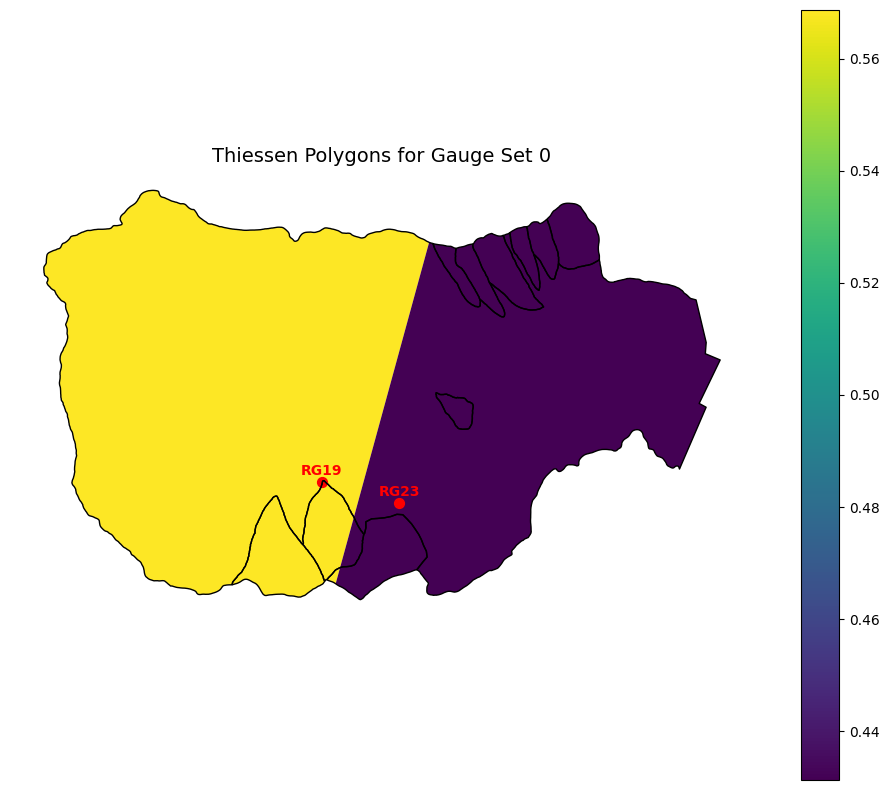

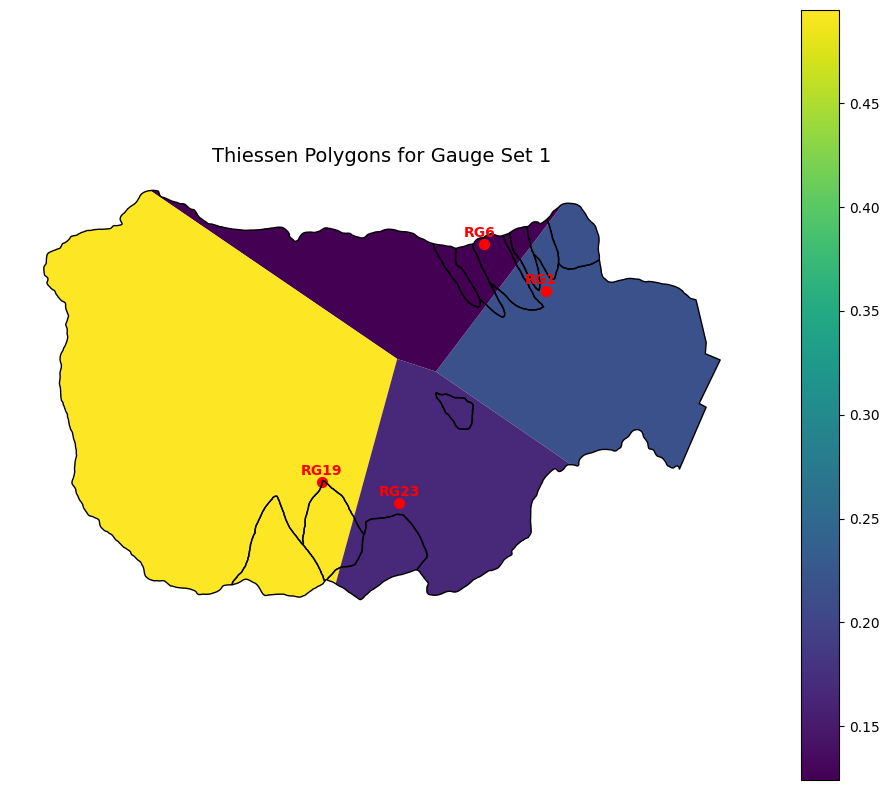

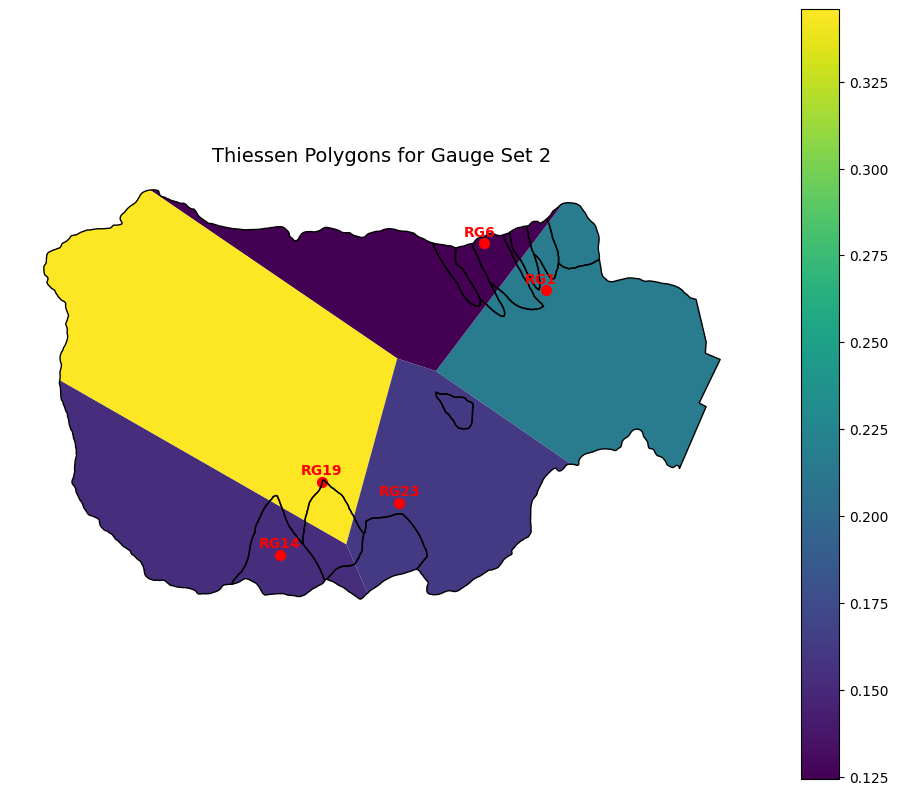

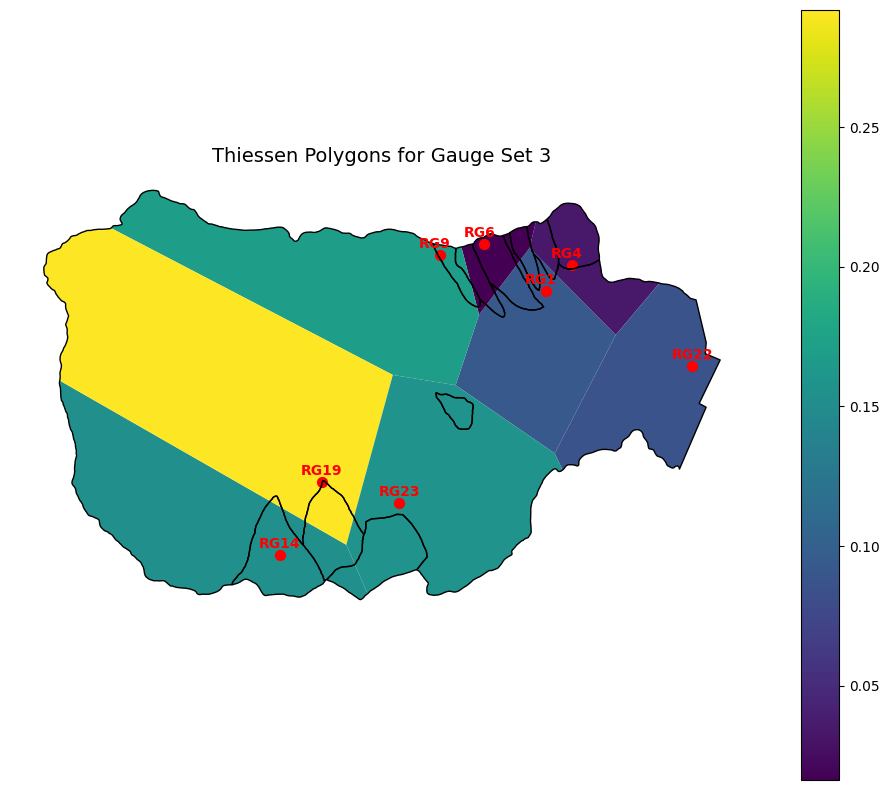

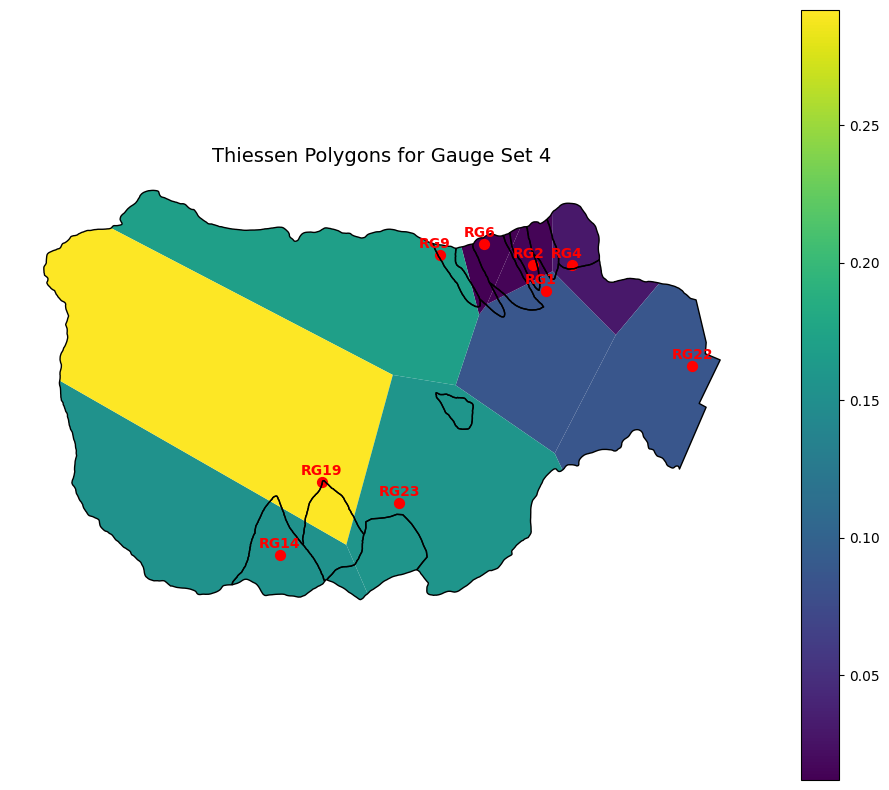

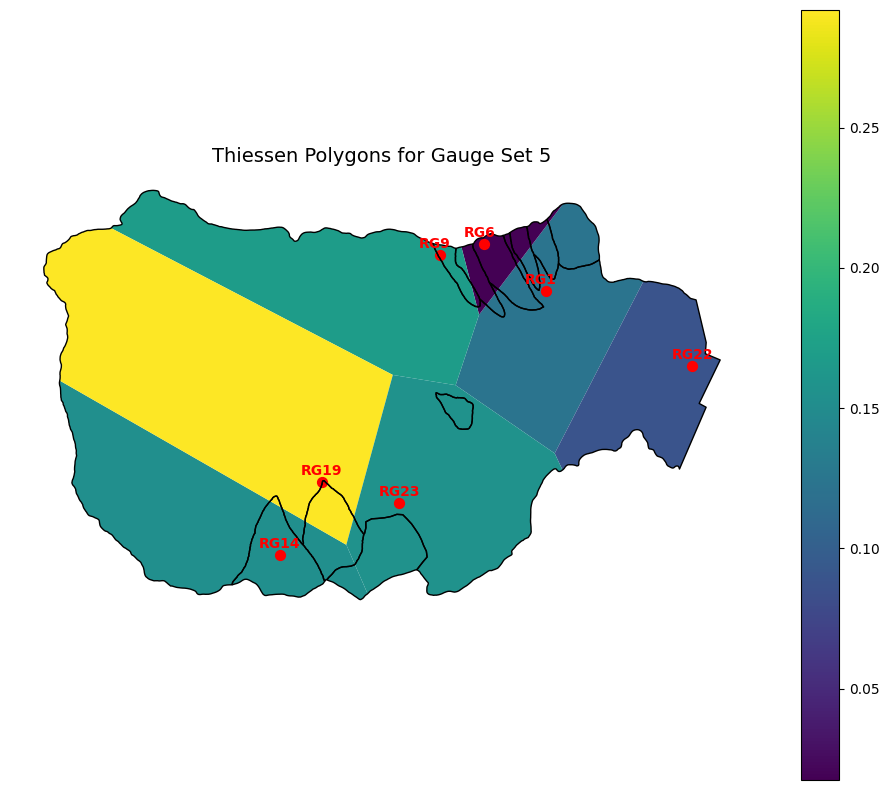

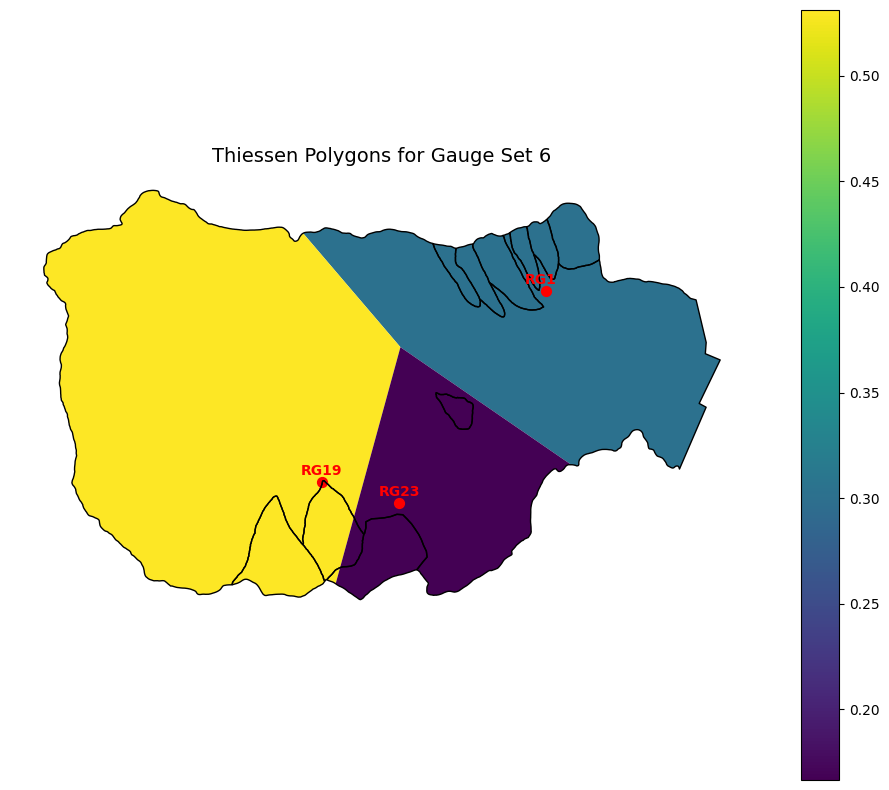

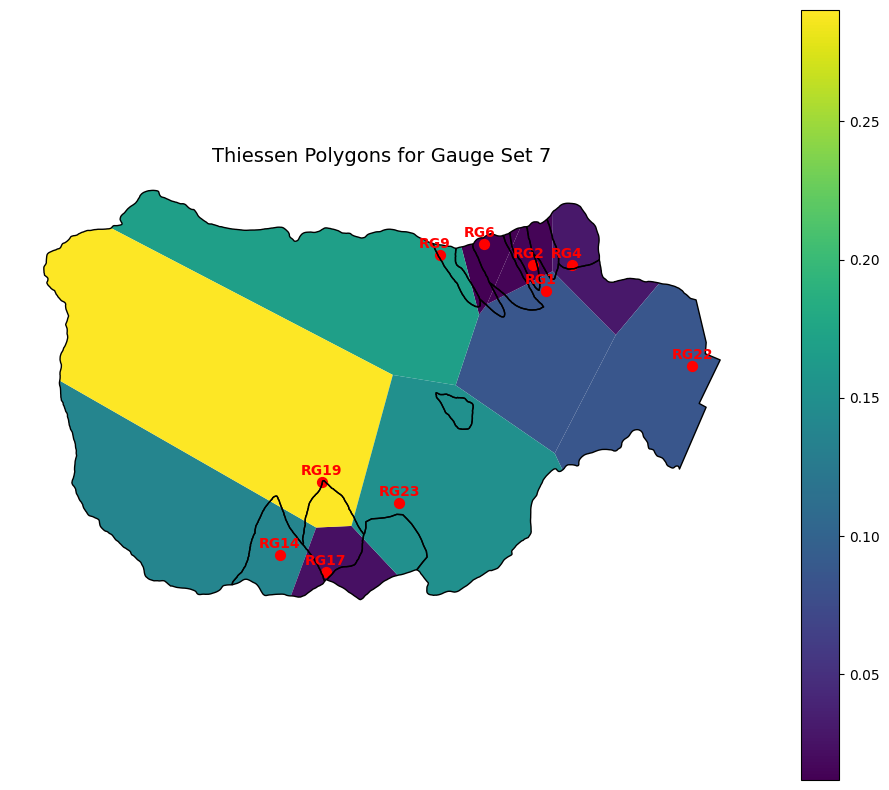

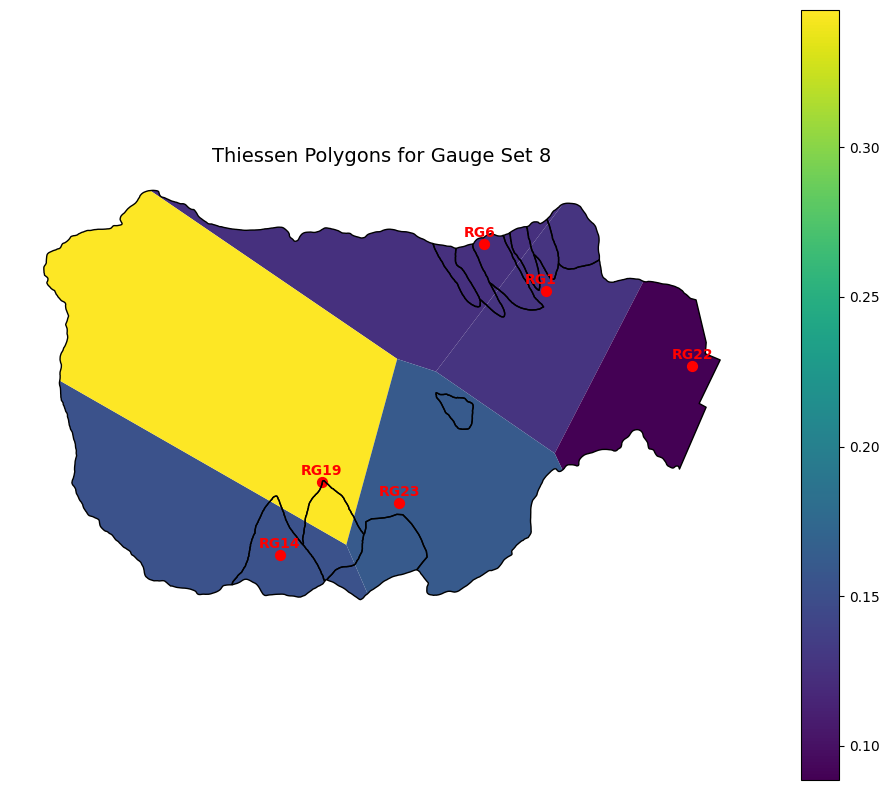

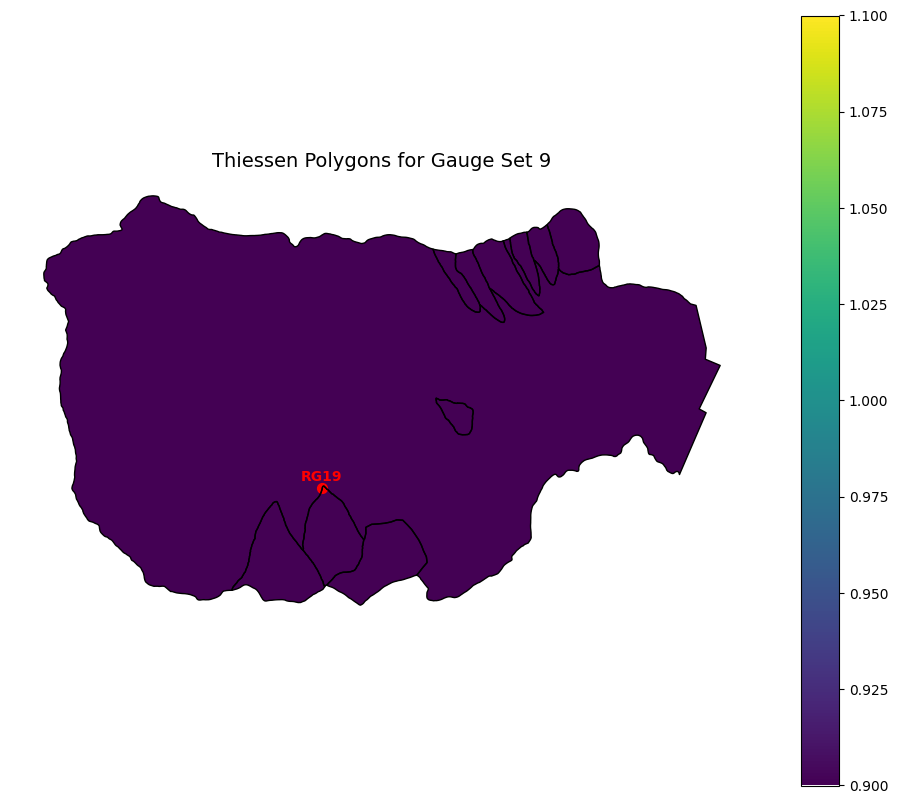

In [ ]:
import matplotlib.pyplot as plt

# Ensure raingauge has integer IDs matching frac_df
if "Gauge_ID" not in raingauge.columns:
    raingauge["Gauge_ID"] = raingauge["Rain_Gauge"].str.replace("RG", "").astype(int)

for i, frac_df in enumerate(frac_lists):
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # Plot watershed boundary
    watershed.boundary.plot(ax=ax, color="black", linewidth=1)

    # Plot Thiessen polygons colored by area fraction
    frac_df.plot(column="area_frac", ax=ax, cmap="viridis", legend=True)

    # Plot active gauges
    gauges_active = frac_df["Rain_Gauge"].tolist()
    raingauge_subset = raingauge[raingauge["Gauge_ID"].isin(gauges_active)]

    if not raingauge_subset.empty:
        raingauge_subset.plot(ax=ax, color="red", markersize=50)

        # Annotate gauges by number only (bold)
        for idx, row in raingauge_subset.iterrows():
            ax.annotate(
                f"RG{row['Gauge_ID']}",
                xy=(row.geometry.x, row.geometry.y),
                xytext=(-15, 5),
                textcoords="offset points",
                fontsize=10,  # larger font
                color="red",
                fontweight="bold",  # bold for readability
            )

    ax.set_title(f"Thiessen Polygons for Gauge Set {i}", fontsize=14)
    ax.set_axis_off()
    plt.show()

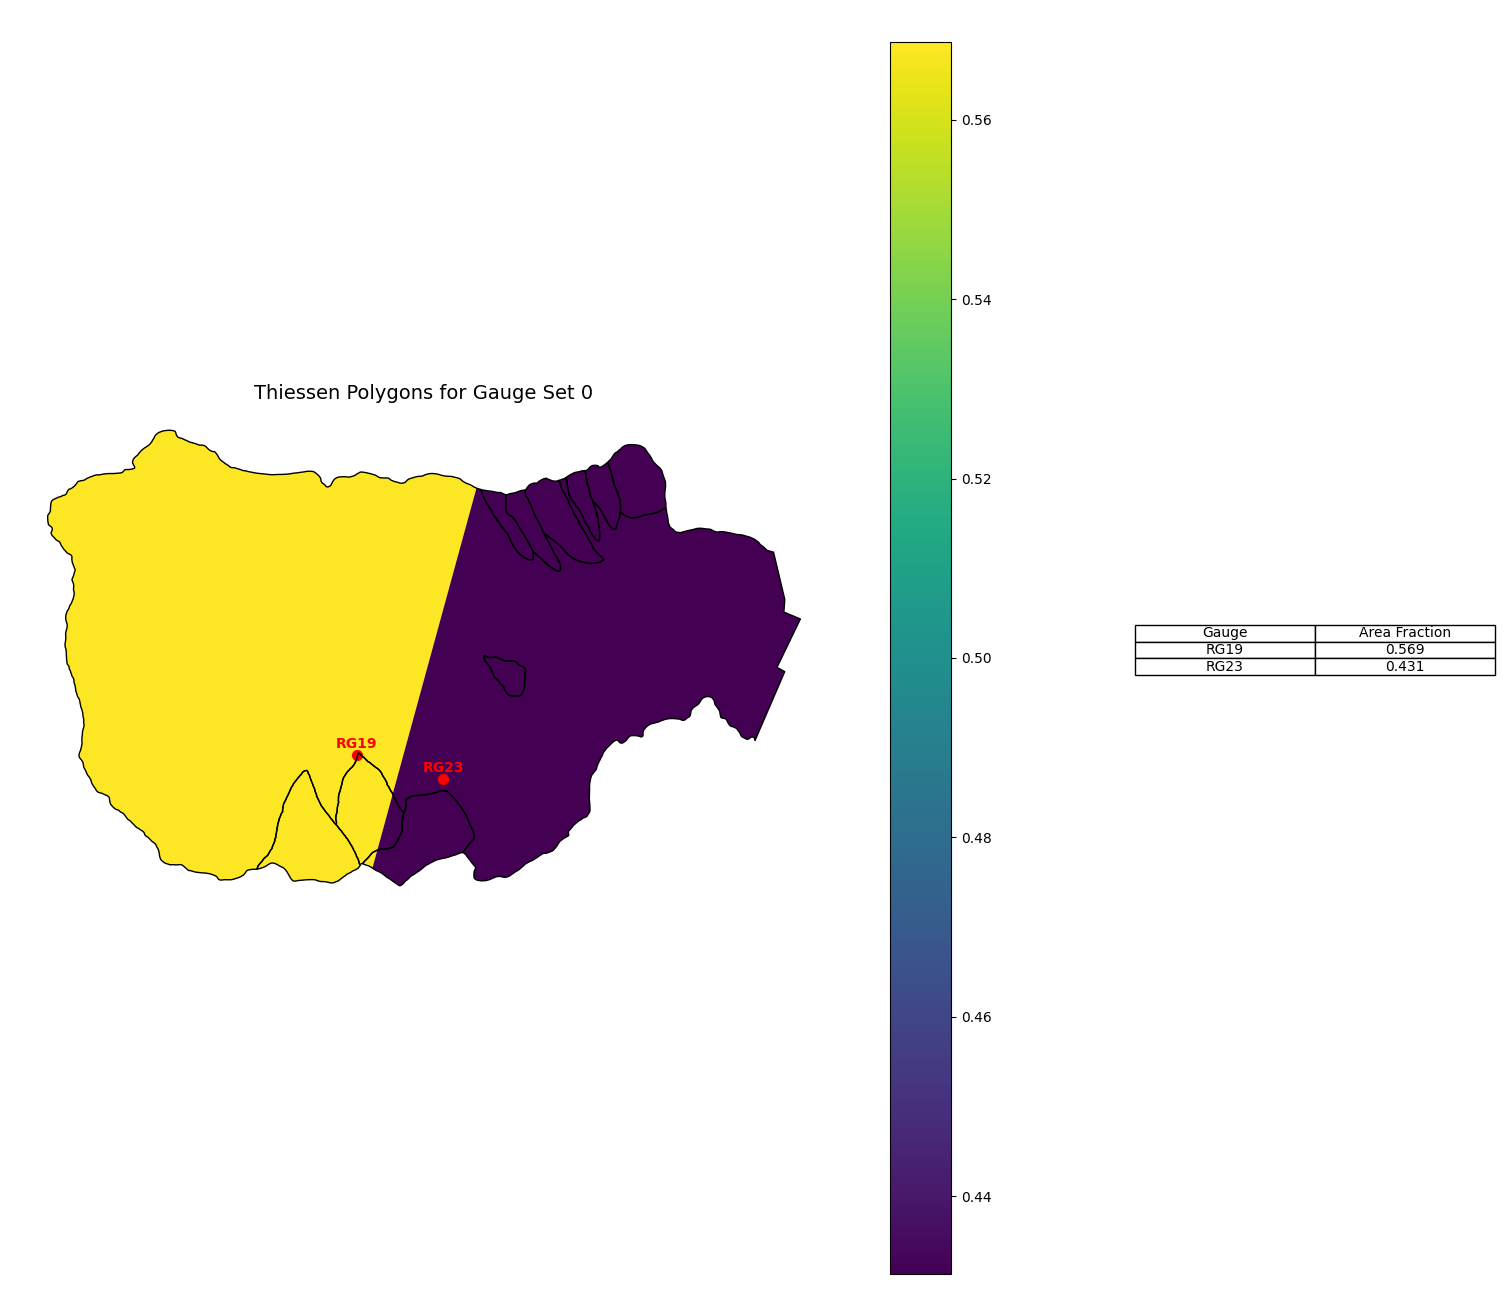

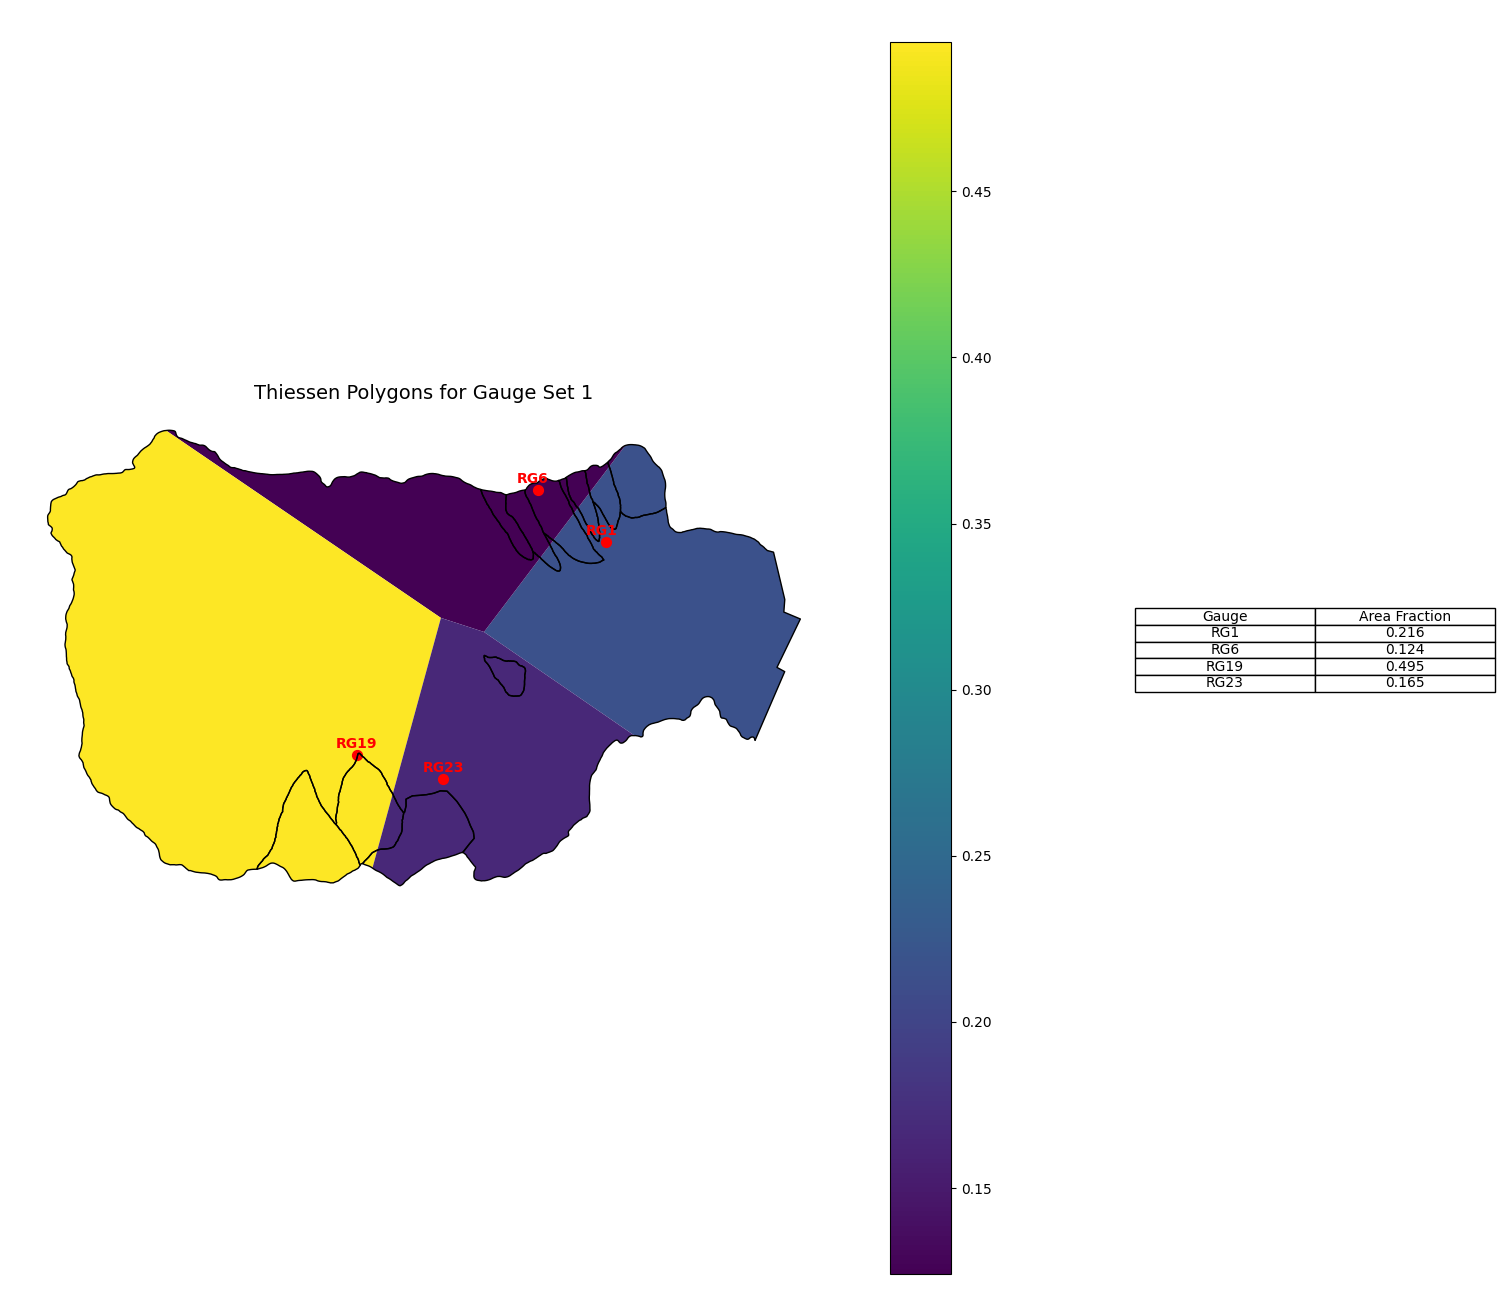

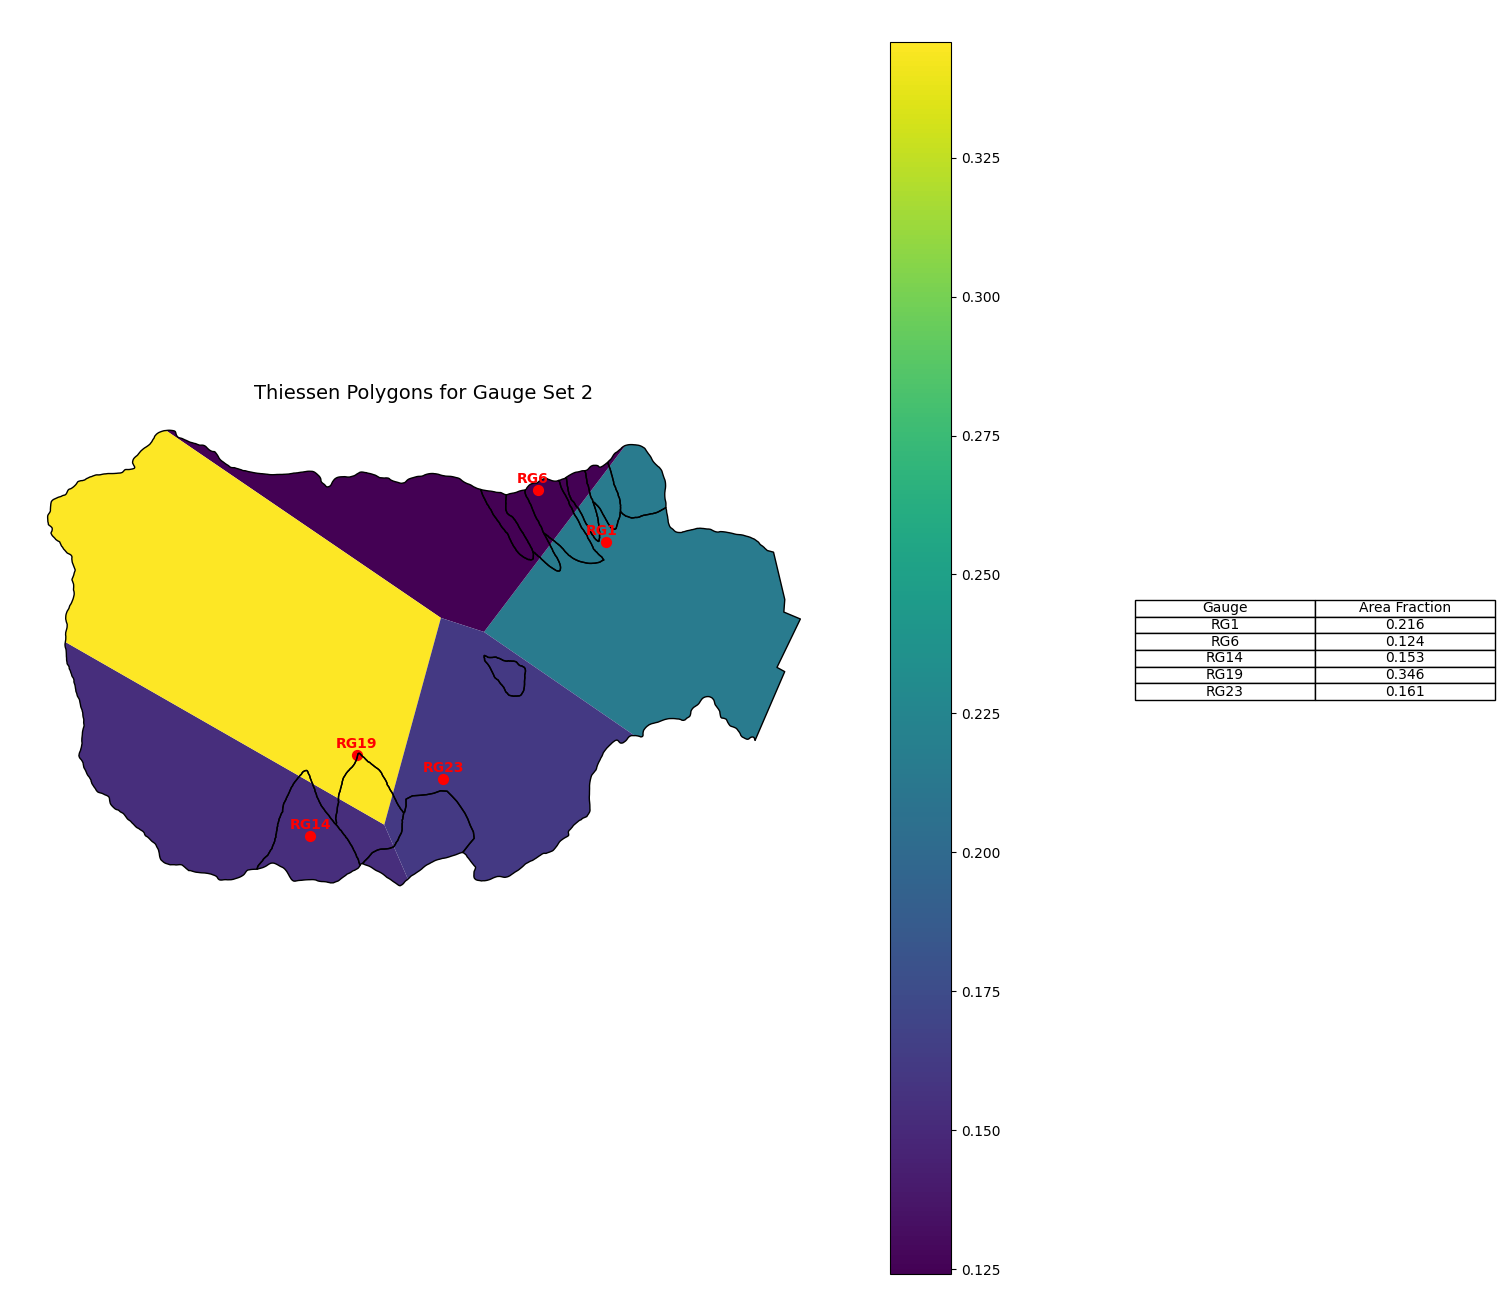

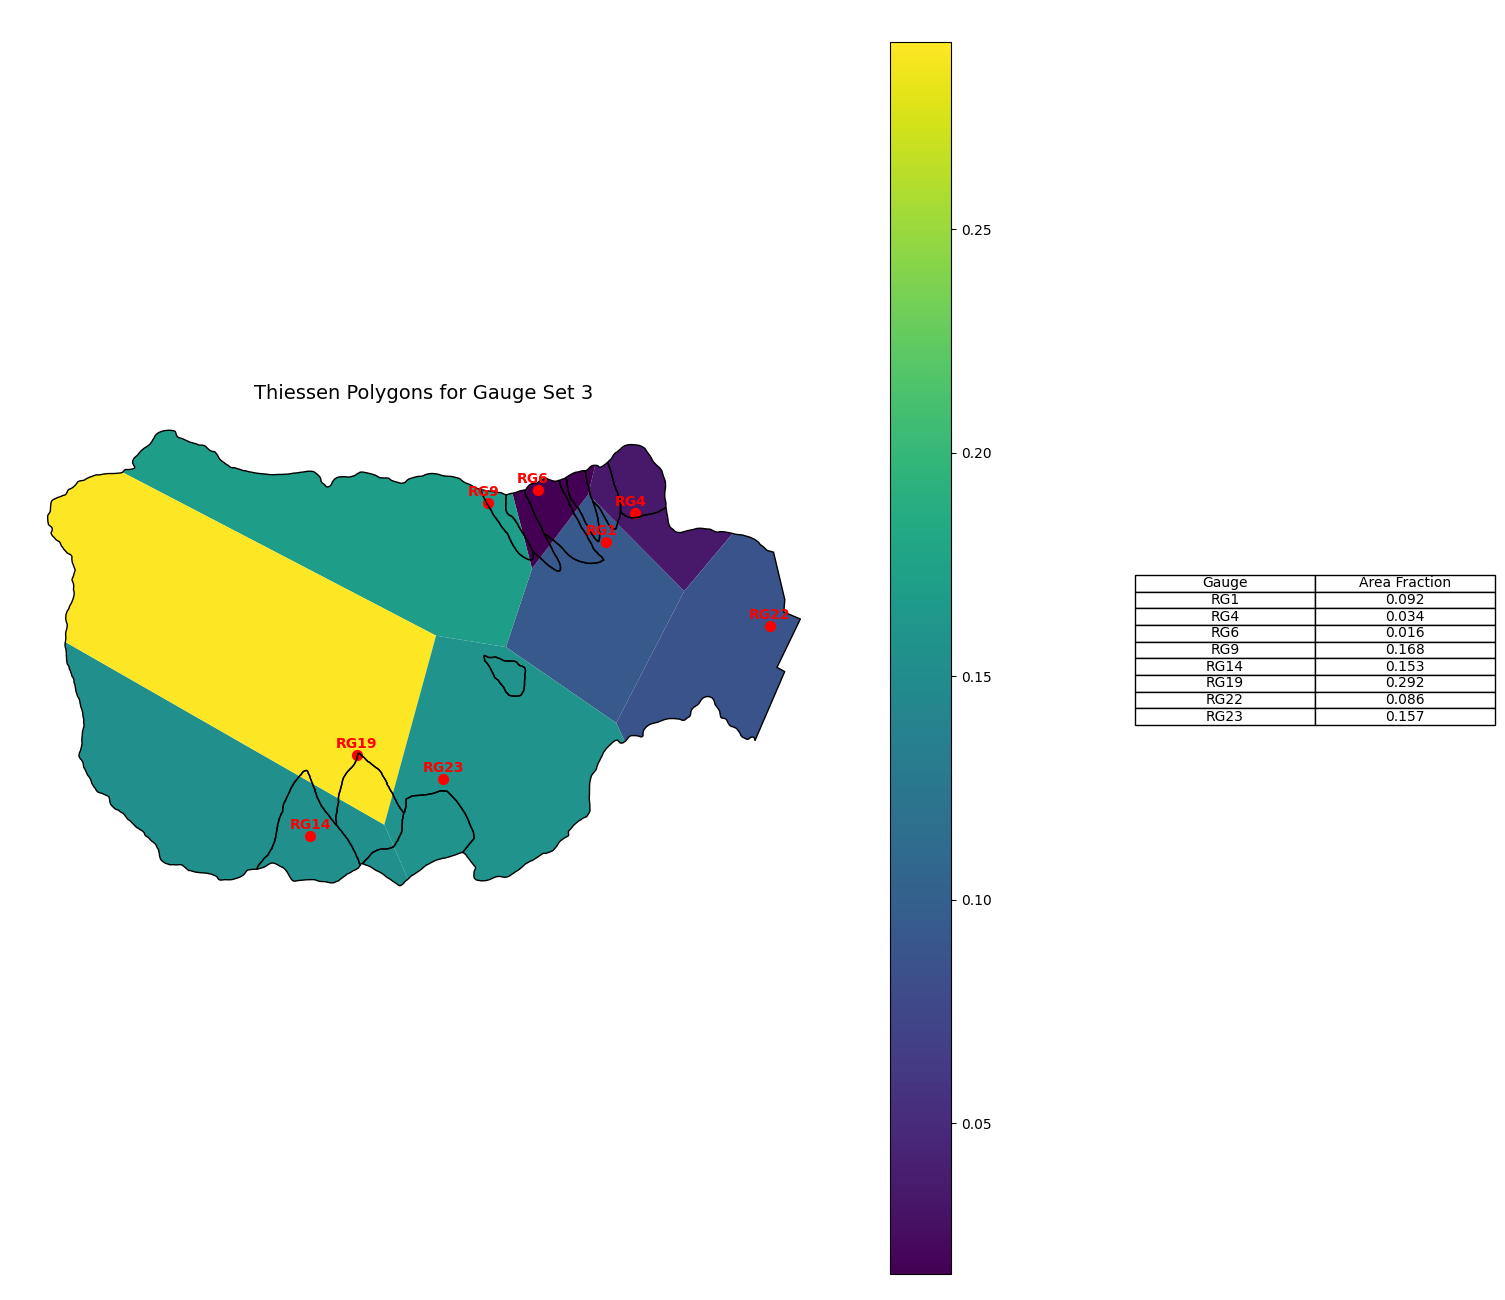

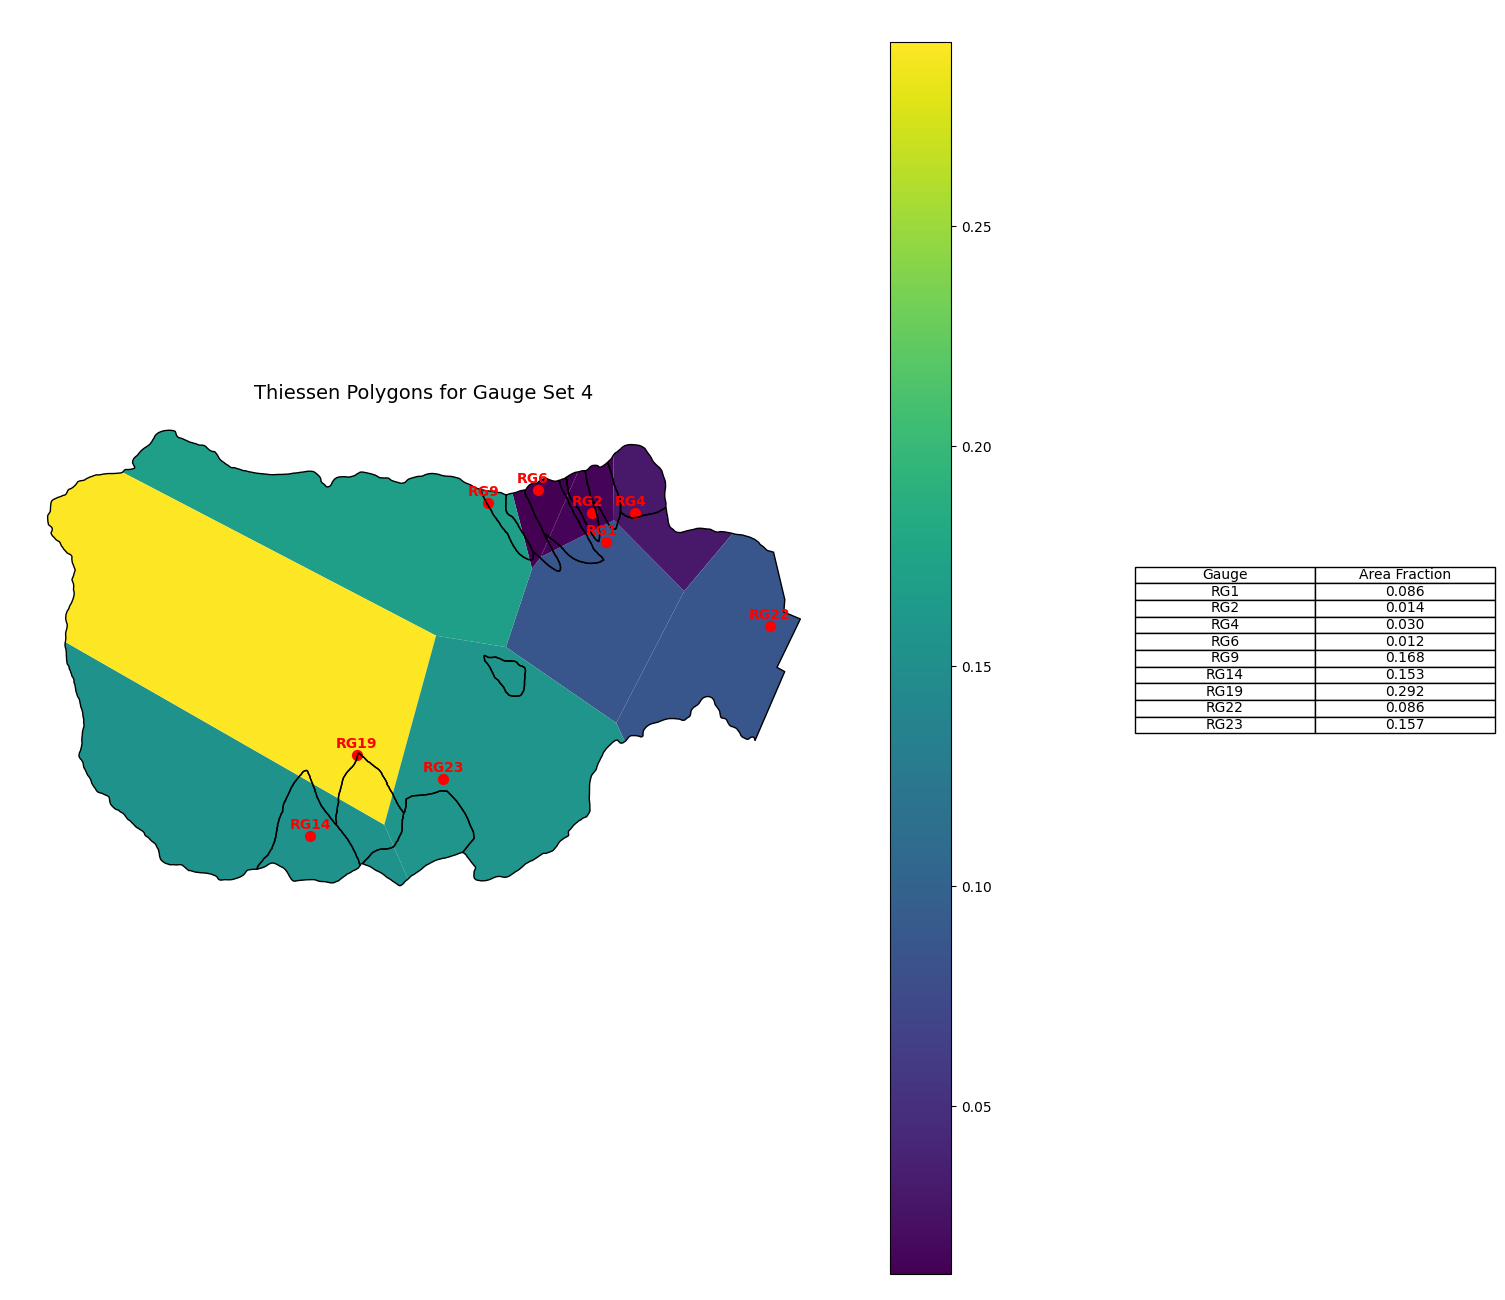

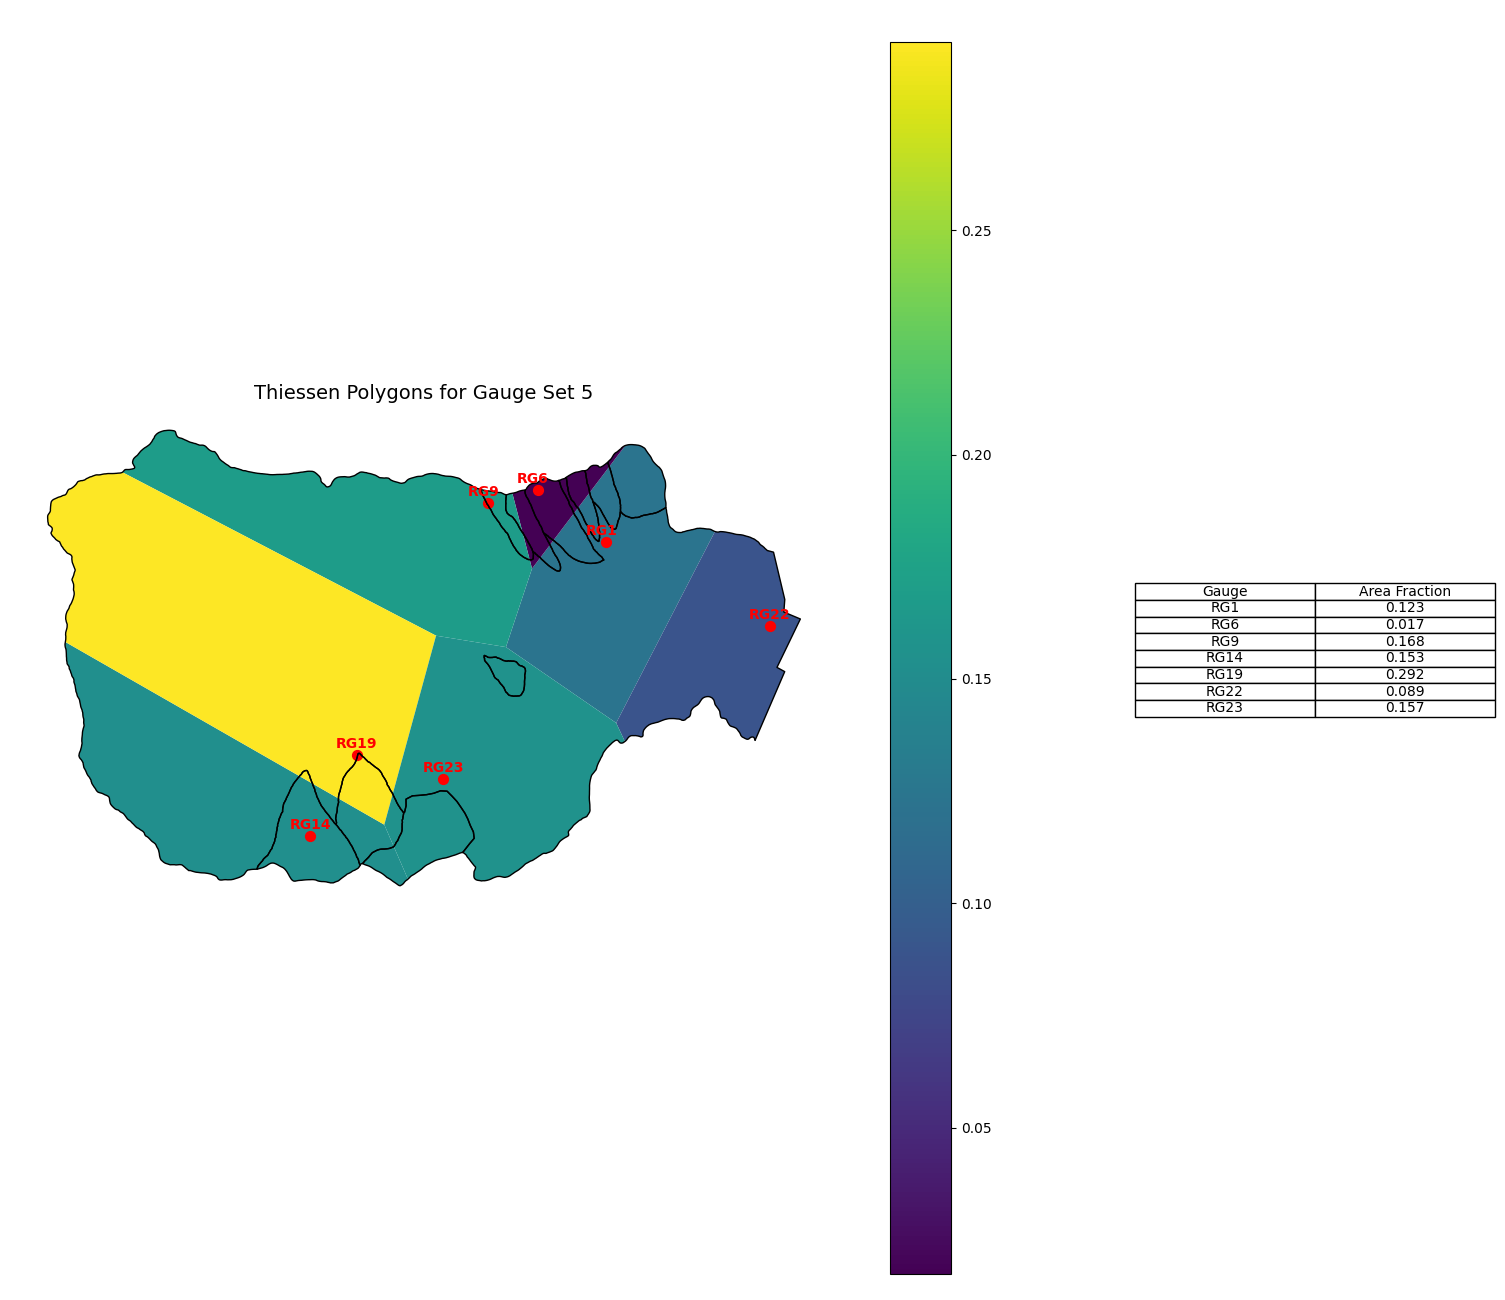

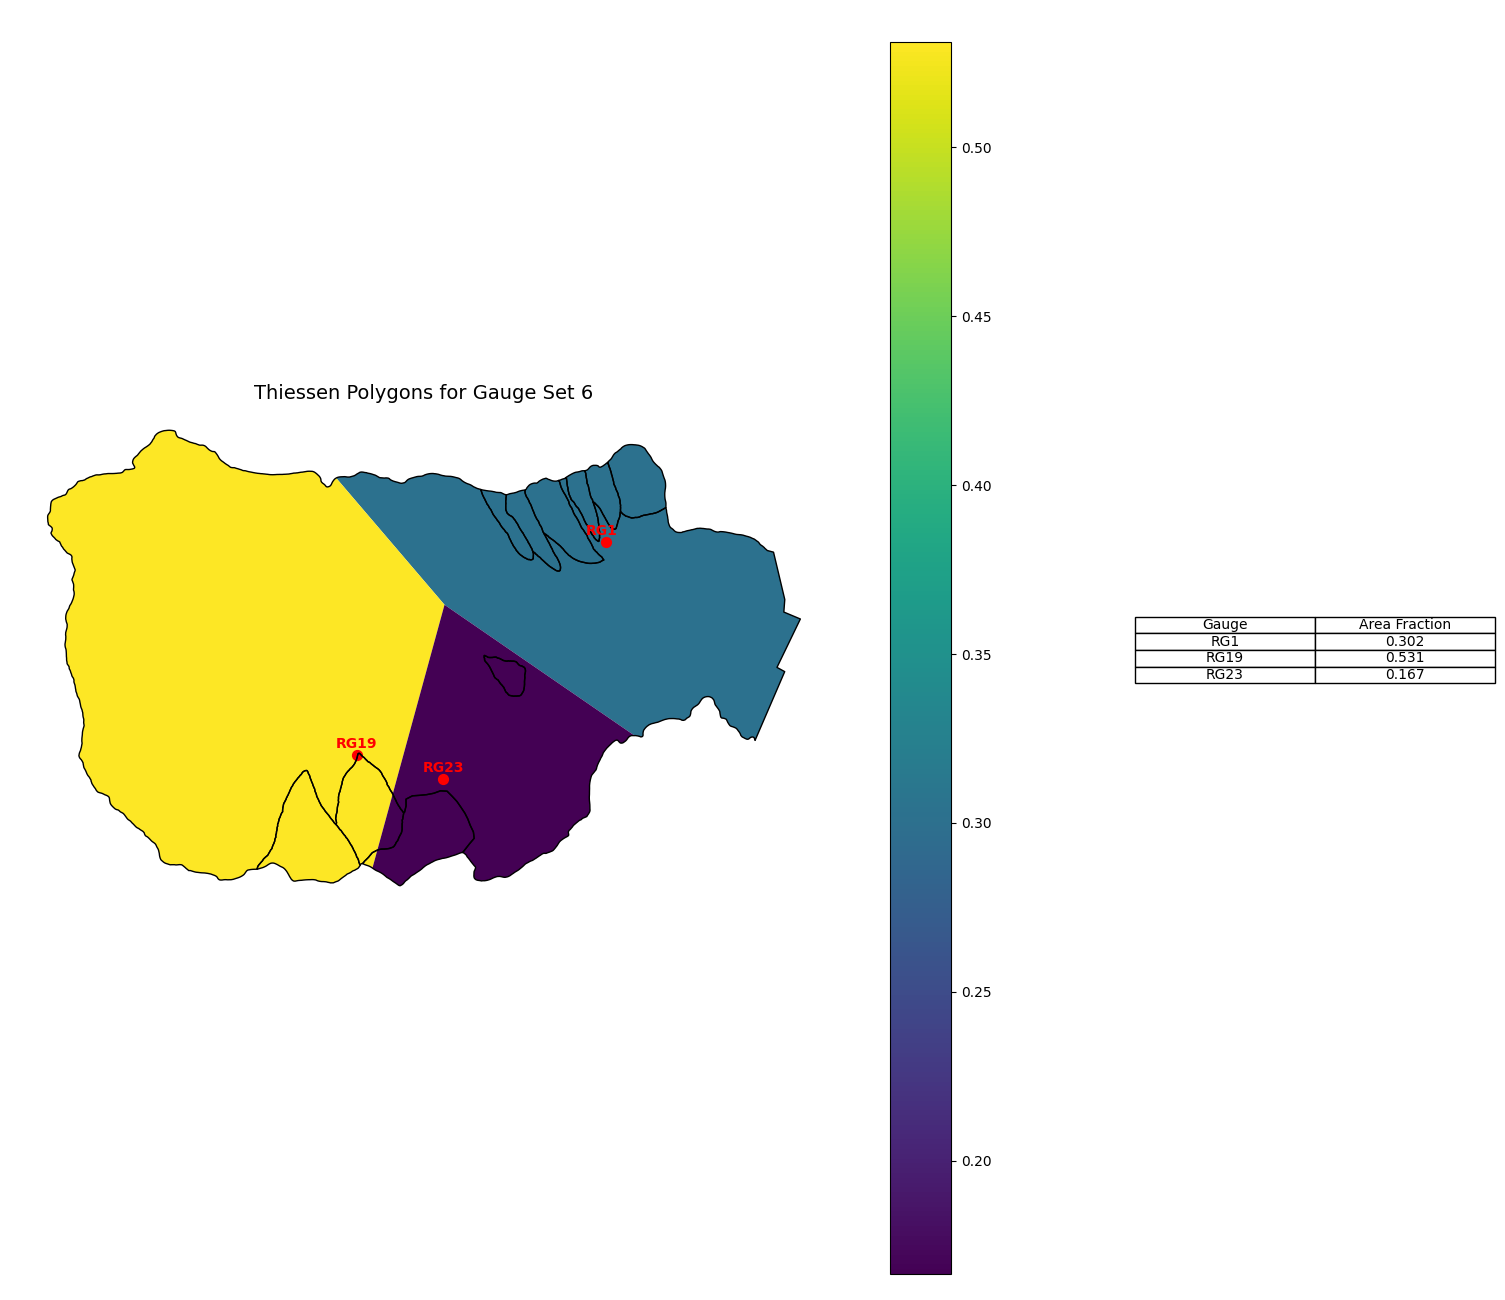

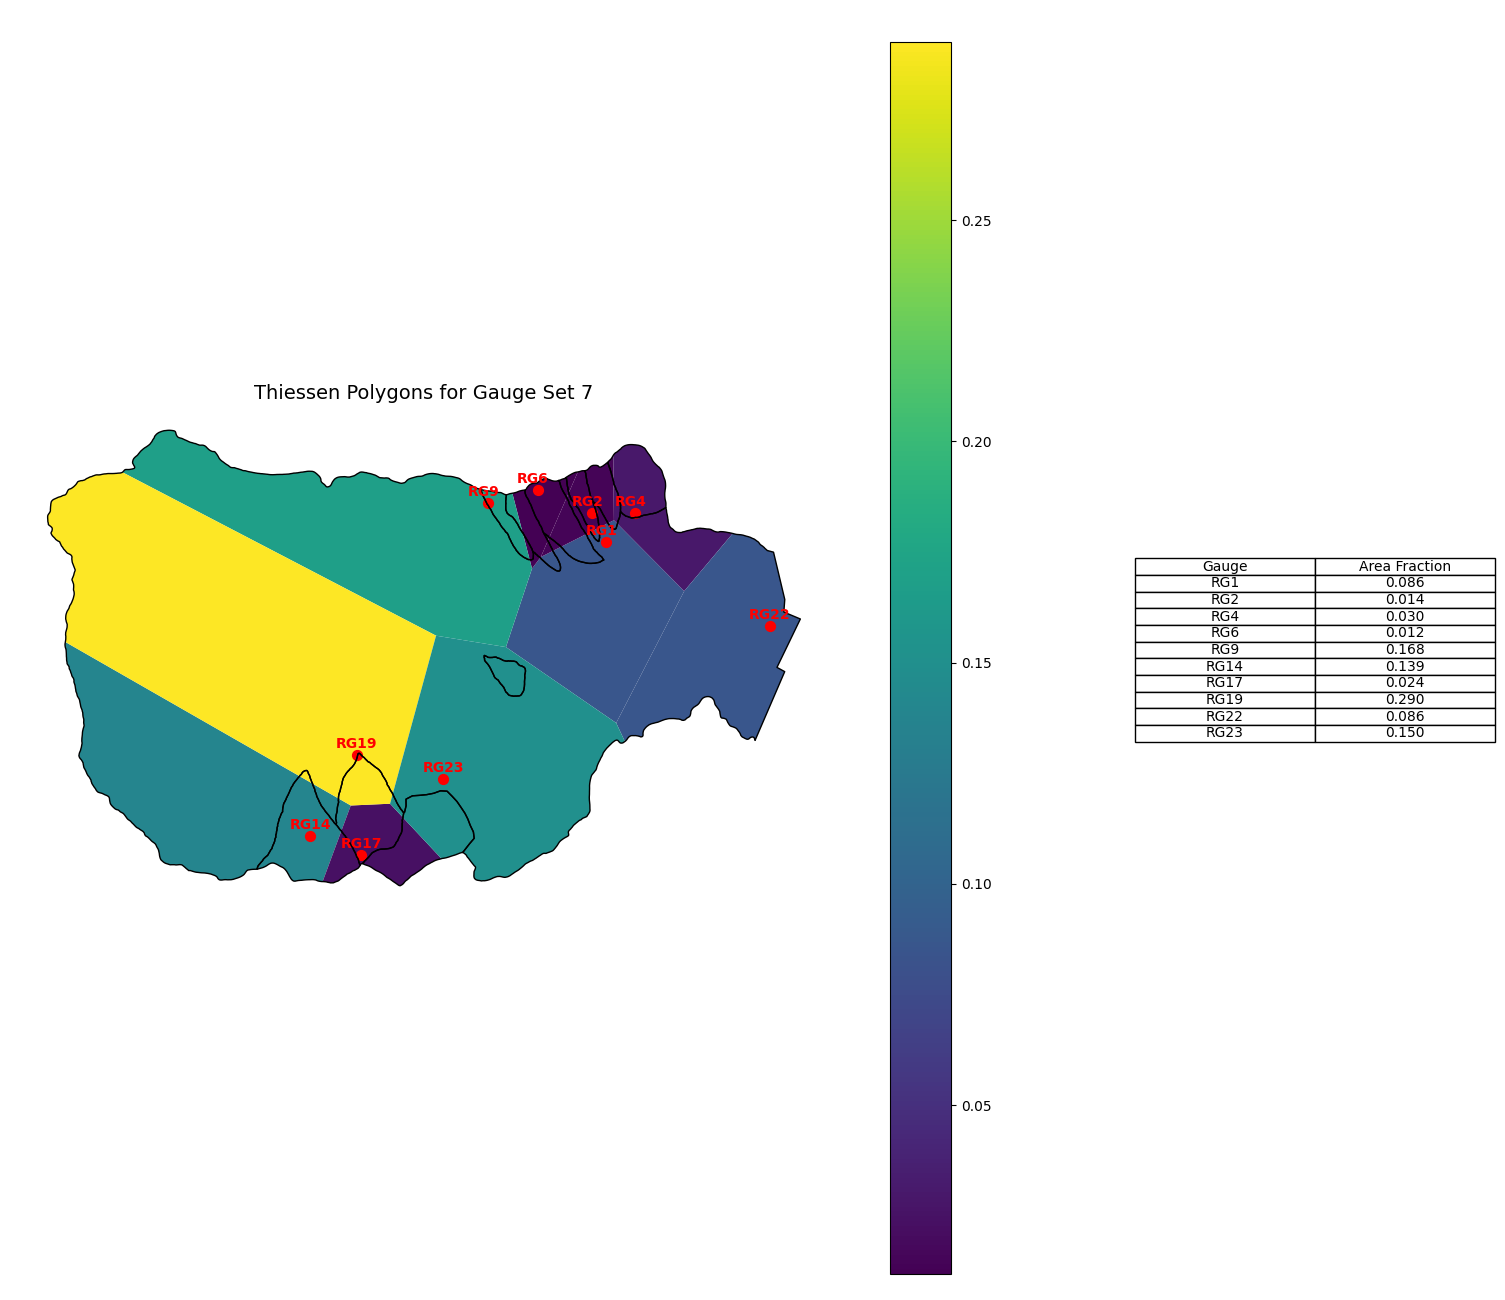

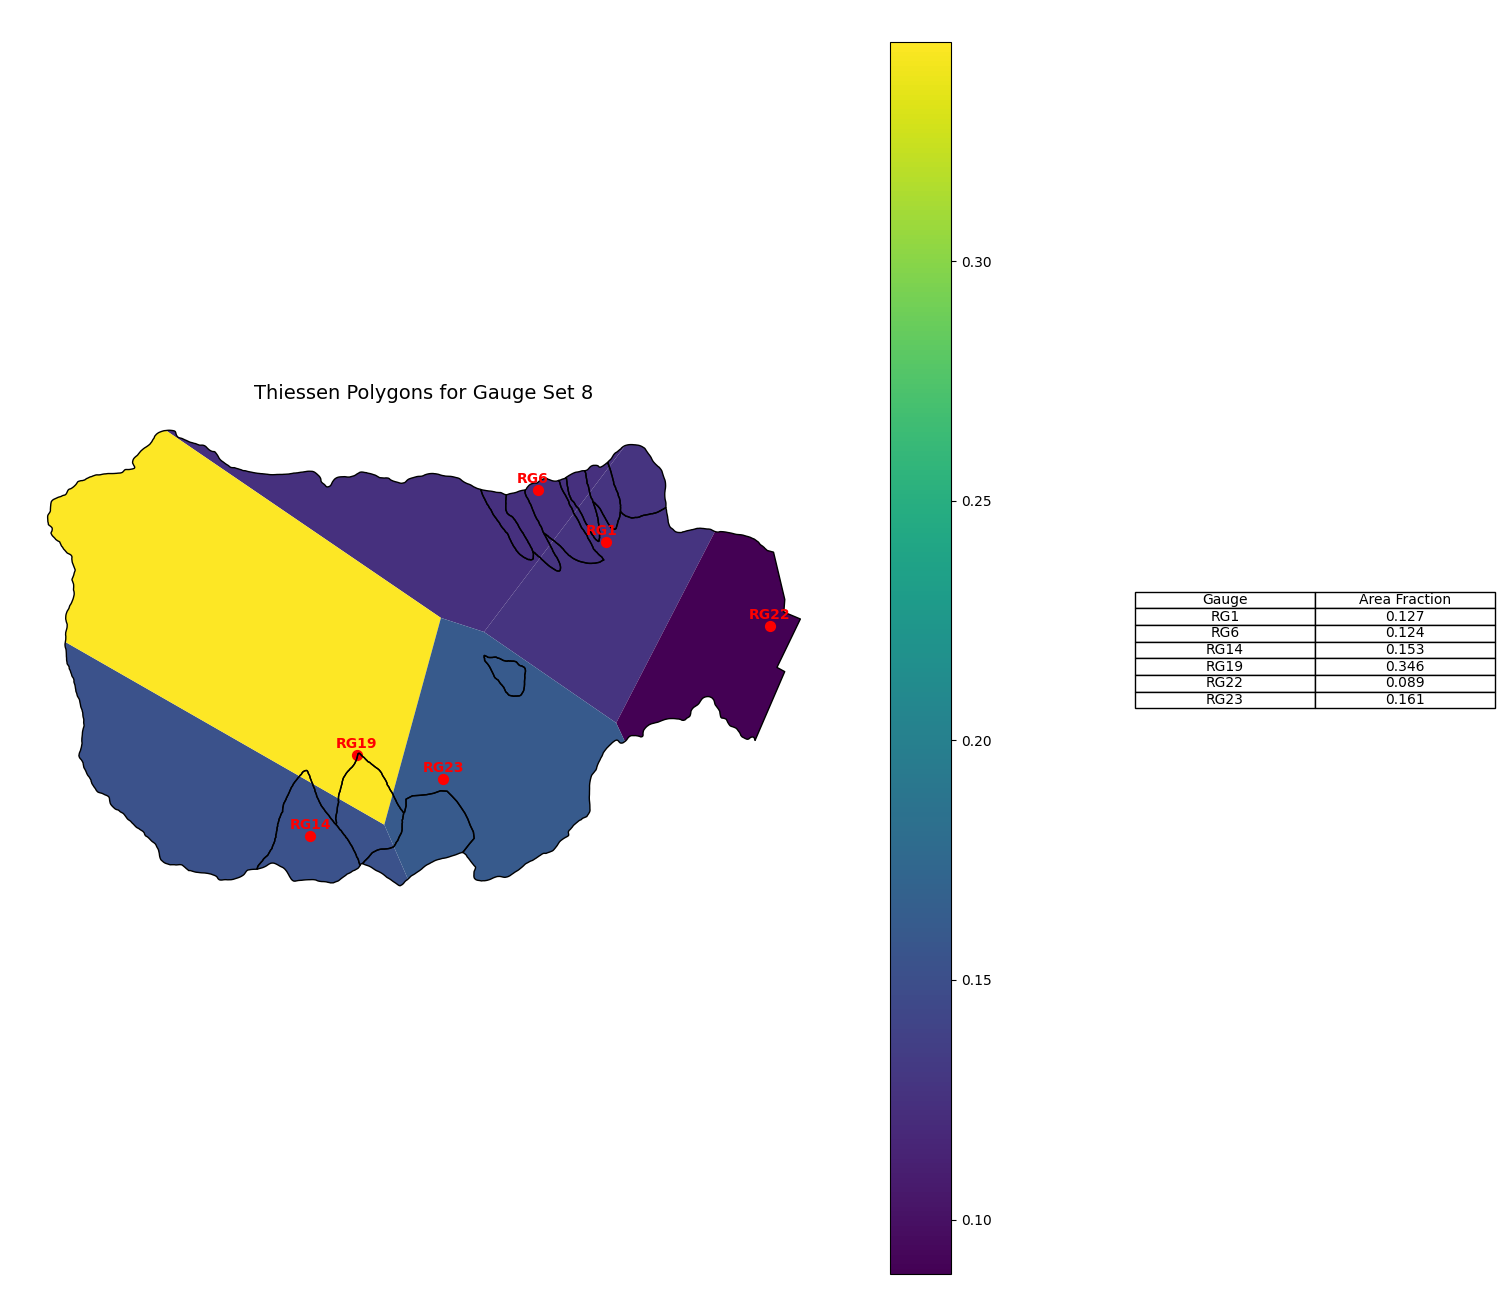

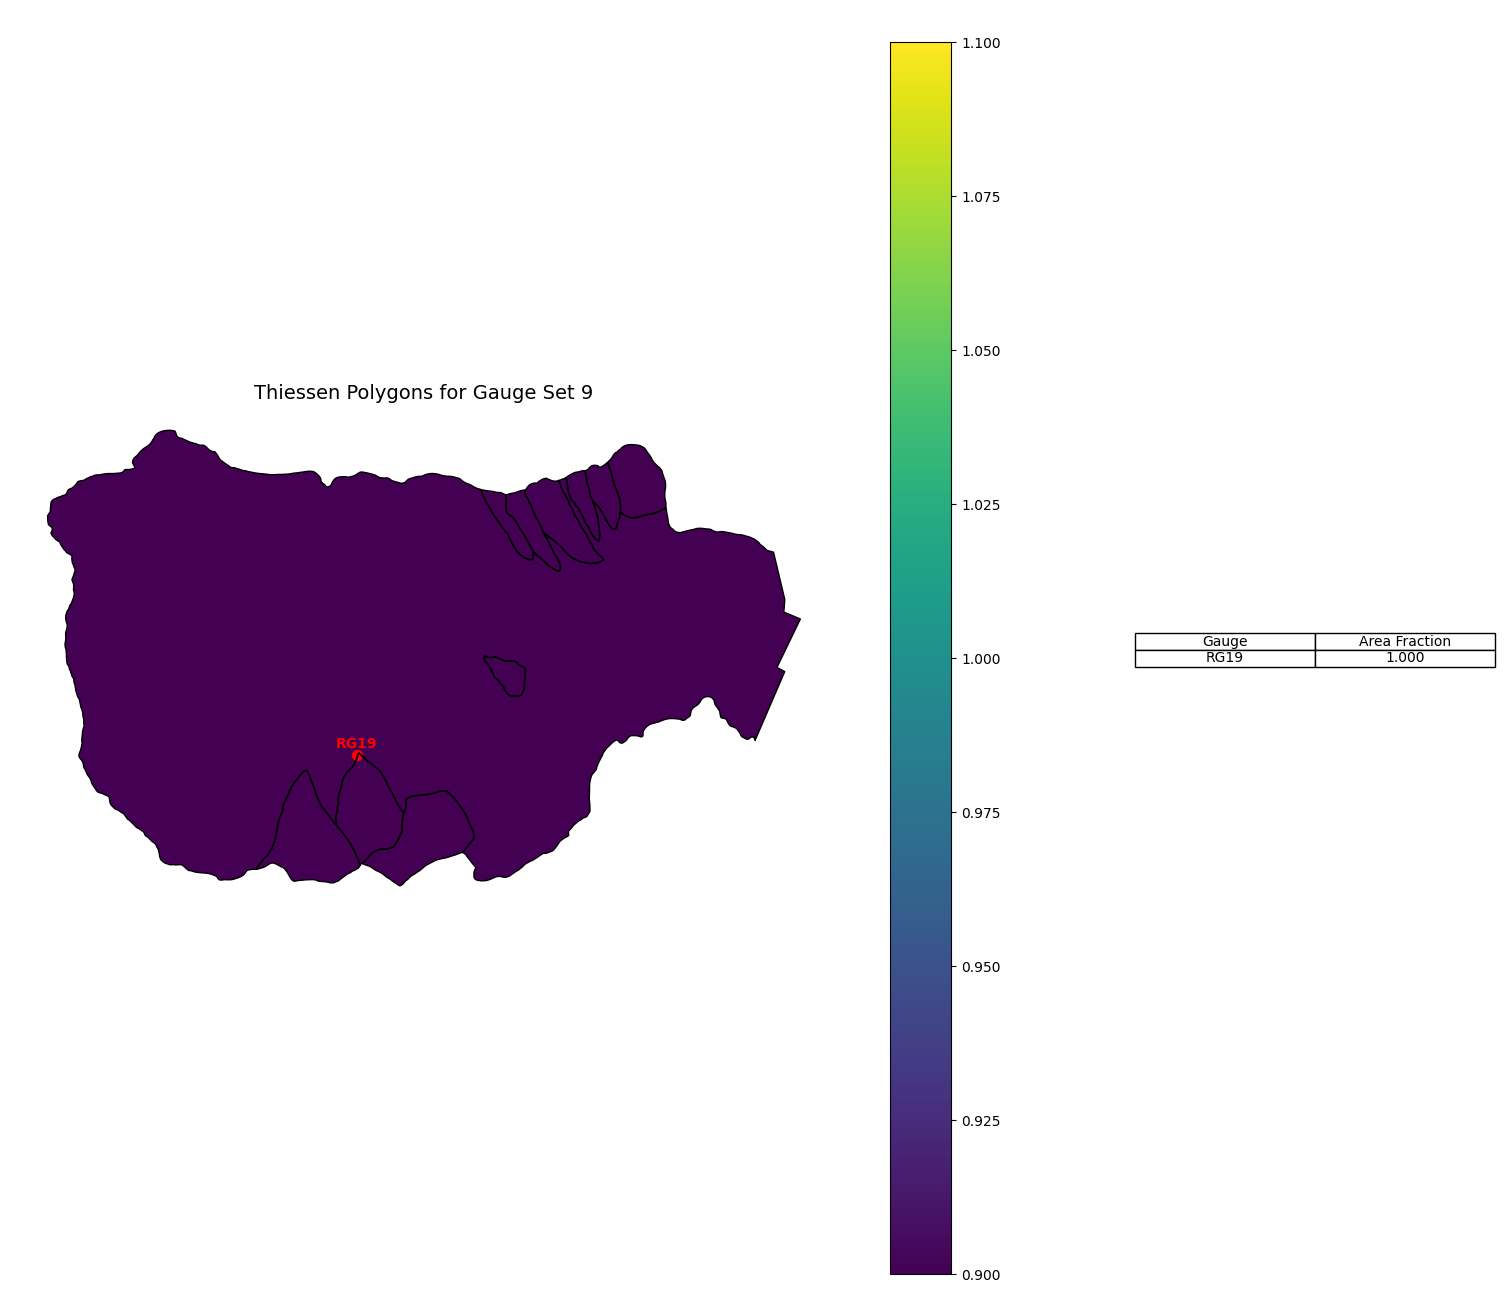

In [ ]:
# Ensure Gauge_ID exists for matching
if "Gauge_ID" not in raingauge.columns:
    raingauge["Gauge_ID"] = raingauge["Rain_Gauge"].str.replace("RG", "").astype(int)

for i, frac_df in enumerate(frac_lists):
    fig, ax = plt.subplots(1, 1, figsize=(18, 16))  # wider figure to fit table

    # Plot watershed boundary
    watershed.boundary.plot(ax=ax, color="black", linewidth=1)

    # Plot Thiessen polygons colored by area fraction
    frac_df.plot(column="area_frac", ax=ax, cmap="viridis", legend=True)

    # Plot active gauges
    gauges_active = frac_df["Rain_Gauge"].tolist()
    raingauge_subset = raingauge[raingauge["Gauge_ID"].isin(gauges_active)]

    if not raingauge_subset.empty:
        raingauge_subset.plot(ax=ax, color="red", markersize=50)

        # Annotate gauges by number only (bold)
        for idx, row in raingauge_subset.iterrows():
            ax.annotate(
                f"RG{row['Gauge_ID']}",
                xy=(row.geometry.x, row.geometry.y),
                xytext=(-15, 5),
                textcoords="offset points",
                fontsize=10,  # larger font for readability
                color="red",
                fontweight="bold",  # bold font
            )

    # Create table data: Gauge | Area Fraction
    table_data = [
        [f"RG{g}", f"{af:.3f}"]
        for g, af in zip(frac_df["Rain_Gauge"], frac_df["area_frac"])
    ]
    col_labels = ["Gauge", "Area Fraction"]

    # Add table to the right side of the plot
    from matplotlib.gridspec import GridSpec

    fig.subplots_adjust(right=0.7)  # leave space for table

    # Place table
    table_ax = fig.add_axes([0.75, 0.1, 0.2, 0.8])  # [left, bottom, width, height]
    table_ax.axis("off")
    table_ax.table(
        cellText=table_data, colLabels=col_labels, loc="center", cellLoc="center"
    )

    ax.set_title(f"Thiessen Polygons for Gauge Set {i}", fontsize=14)
    ax.set_axis_off()
    plt.show()

Idea from Dr. Nara for project: Use DEM to get slope and varience of slpoe for each of the polygons, vegetation coverage, instead of just area